In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
CSV_PATH = "wpd_datasets.csv"  # change if needed

def extract_xy(df, xcol, ycol):
    """Extract numeric arrays, skipping the first row with 'X'/'Y'."""
    sub = df[[xcol, ycol]].iloc[1:].copy()
    sub.columns = ["x", "y"]
    sub = sub.apply(pd.to_numeric, errors="coerce").dropna()
    return sub["x"].to_numpy(), sub["y"].to_numpy()

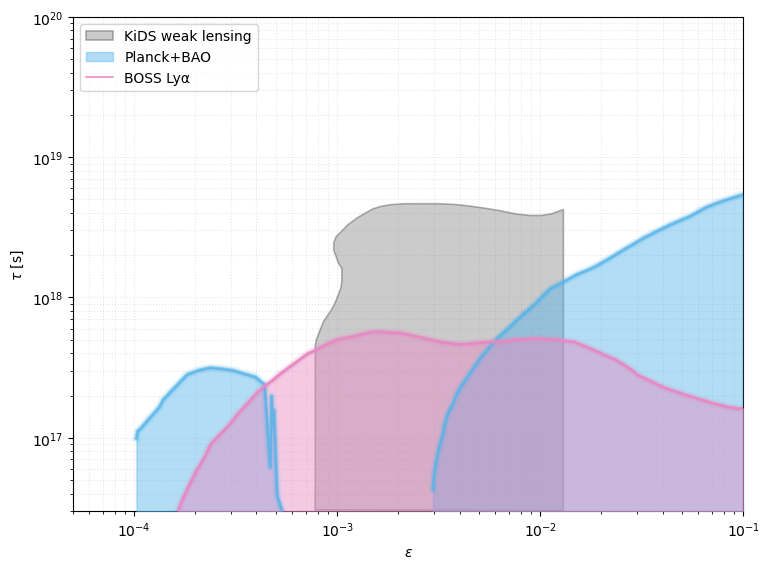

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "wpd_datasets.csv"  # change if needed

def extract_xy(df, xcol, ycol):
    """Extract numeric arrays, skipping the first row with 'X'/'Y'."""
    sub = df[[xcol, ycol]].iloc[1:].copy()
    sub.columns = ["x", "y"]
    sub = sub.apply(pd.to_numeric, errors="coerce").dropna()
    x = sub["x"].to_numpy()
    y = sub["y"].to_numpy()
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[m], y[m]

def prep_curve(x, y):
    """
    Make a single-valued y(x) curve:
      - sort by x
      - for duplicate x, take max y (upper boundary)
    """
    order = np.argsort(x)
    x, y = x[order], y[order]
    ux, inv = np.unique(x, return_inverse=True)
    y_max = np.zeros_like(ux, dtype=float)
    for i in range(len(ux)):
        y_max[i] = np.max(y[inv == i])
    return ux, y_max

def smooth_loglog_curve(x, y, n=500):
    """
    Smooth a boundary curve by interpolating in log-log space to a dense grid.
    This fixes the 'weird left part' caused by sparse/non-uniform sampling.
    """
    x, y = prep_curve(x, y)

    # Ensure strictly increasing x and positive y
    m = (x > 0) & (y > 0)
    x, y = x[m], y[m]

    lx = np.log10(x)
    ly = np.log10(y)

    # Dense x grid spanning the curve support
    xg = np.logspace(lx.min(), lx.max(), n)
    lyg = np.interp(np.log10(xg), lx, ly)  # linear interp in log space
    yg = 10**lyg
    return xg, yg

def glow_line(ax, x, y, color, zorder=10):
    """Soft/blurred boundary: draw the same line multiple times."""
    for lw, a in [(6.0, 0.12), (4.0, 0.18), (2.5, 0.35), (1.8, 0.65)]:
        ax.plot(x, y, color=color, lw=lw, alpha=a, zorder=zorder)

# -----------------------------
# Load data
# -----------------------------
raw = pd.read_csv(CSV_PATH)

kids_x, kids_y = extract_xy(raw, "Default Dataset", "Unnamed: 1")
p1_x, p1_y     = extract_xy(raw, "Dataset 1",      "Unnamed: 3")
p2_x, p2_y     = extract_xy(raw, "Dataset 2",      "Unnamed: 5")
boss_x, boss_y = extract_xy(raw, "BOSS",           "Unnamed: 7")

# Smooth boundary curves (Planck+BAO and BOSS)
p1_xs, p1_ys = smooth_loglog_curve(p1_x, p1_y, n=500)
p2_xs, p2_ys = smooth_loglog_curve(p2_x, p2_y, n=500)
boss_xs, boss_ys = smooth_loglog_curve(boss_x, boss_y, n=600)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.8, 5.8))
ax.set_xscale("log")
ax.set_yscale("log")

# Limits (match the paper-like framing)
x_min, x_max = 5e-5, 1e-1
tau_min, tau_max = 3e16, 1e20
ax.set_xlim(x_min, x_max)
ax.set_ylim(tau_min, tau_max)

# Colors (you can tweak)
c_kids   = "#8c8c8c"
c_planck = "#56B4E9"   # blue/cyan
c_boss   = "#e78ac3"   # pink

# 1) KiDS (unchanged: polygon fill)
ax.fill(kids_x, kids_y,
        facecolor=c_kids, edgecolor="#555555",
        alpha=0.45, linewidth=1.2,
        label="KiDS weak lensing", zorder=2)

# 2) Planck+BAO: fill EVERYTHING below each boundary down to tau_min (no triangles)
ax.fill_between(p1_xs, tau_min, p1_ys,
                color=c_planck, alpha=0.45, zorder=3, label="Planck+BAO")
ax.fill_between(p2_xs, tau_min, p2_ys,
                color=c_planck, alpha=0.45, zorder=3, label="_nolegend_")

# Blurred/glow boundary for Planck+BAO
glow_line(ax, p1_xs, p1_ys, color=c_planck, zorder=6)
glow_line(ax, p2_xs, p2_ys, color=c_planck, zorder=6)

# 3) BOSS Lyα: line + fill below
ax.fill_between(boss_xs, tau_min, boss_ys,
                color=c_boss, alpha=0.45, zorder=4, label="_nolegend_")
glow_line(ax, boss_xs, boss_ys, color=c_boss, zorder=7)
ax.plot(boss_xs, boss_ys, color=c_boss, lw=1.2, alpha=0.95, label="BOSS Lyα", zorder=8)

# Labels / legend / grid
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$\tau$ [s]")

ax.grid(True, which="both", ls=":", alpha=0.30)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

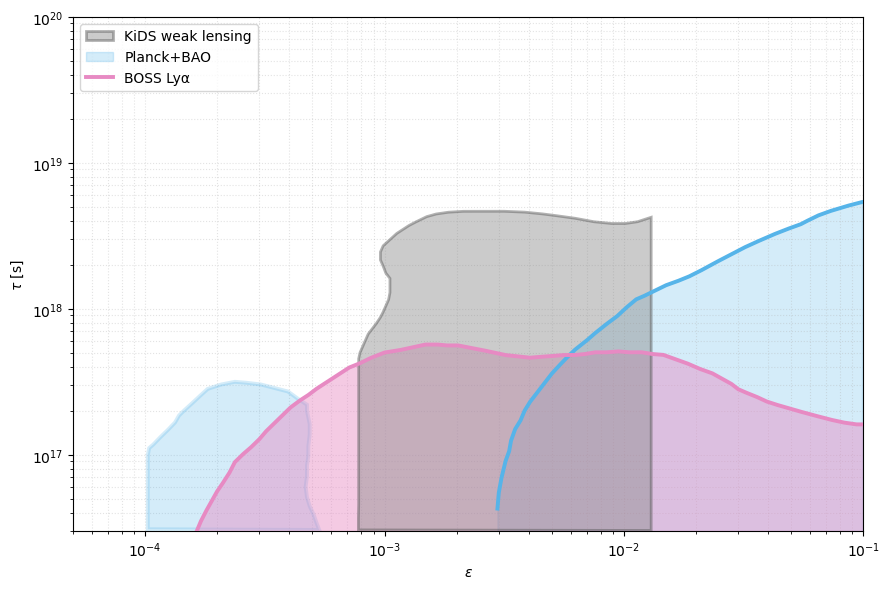

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

CSV_PATH = "wpd_datasets.csv"

def extract_xy(df, xcol, ycol):
    sub = df[[xcol, ycol]].iloc[1:].copy()
    sub.columns = ["x", "y"]
    sub = sub.apply(pd.to_numeric, errors="coerce").dropna()
    x = sub["x"].to_numpy()
    y = sub["y"].to_numpy()
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[m], y[m]

def prep_upper_envelope(x, y):
    """
    Build an upper boundary y_upper(x) for fill_between:
      - sort by x
      - for duplicate x, keep MAX y
    """
    order = np.argsort(x)
    x, y = x[order], y[order]
    ux, inv = np.unique(x, return_inverse=True)
    y_max = np.zeros_like(ux, dtype=float)
    for i in range(len(ux)):
        y_max[i] = np.max(y[inv == i])
    return ux, y_max

def add_polygon(ax, x, y, *, facecolor, alpha, edgecolor=None, lw=2.5, label=None, zorder=1):
    xy = np.column_stack([x, y])
    patch = Polygon(
        xy, closed=True,
        facecolor=facecolor, alpha=alpha,
        edgecolor=edgecolor if edgecolor is not None else facecolor,
        linewidth=lw,
        label=label,
        zorder=zorder
    )
    ax.add_patch(patch)
    return patch

raw = pd.read_csv(CSV_PATH)

kids_x, kids_y = extract_xy(raw, "Default Dataset", "Unnamed: 1")
p1_x, p1_y     = extract_xy(raw, "Dataset 1",      "Unnamed: 3")  # right "below boundary"
p2_x, p2_y     = extract_xy(raw, "Dataset 2",      "Unnamed: 5")  # left "island"
boss_x, boss_y = extract_xy(raw, "BOSS",           "Unnamed: 7")

# Axis limits
x_min, x_max = 5e-5, 1e-1
tau_min, tau_max = 3e16, 1e20

# Colors
c_planck = "#56B4E9"
c_boss   = "#e78ac3"
c_kids   = "#8c8c8c"

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(x_min, x_max)
ax.set_ylim(tau_min, tau_max)

# -------------------------
# KiDS: polygon (as before)
# -------------------------
add_polygon(ax, kids_x, kids_y,
            facecolor=c_kids, alpha=0.45, edgecolor="#555555",
            lw=2.0, label="KiDS weak lensing", zorder=3)

# -------------------------------------------
# Planck+BAO right part: fill BELOW boundary
# -------------------------------------------
p1_xu, p1_yu = prep_upper_envelope(p1_x, p1_y)
ax.fill_between(p1_xu, tau_min, p1_yu, color=c_planck, alpha=0.25, zorder=1, label="Planck+BAO")
ax.plot(p1_xu, p1_yu, color=c_planck, lw=2.8, zorder=10)  # boundary on top

# -------------------------------------------
# Planck+BAO left part: this is an ISLAND
# fill it as a polygon, with edge as boundary
# -------------------------------------------
add_polygon(ax, p2_x, p2_y,
            facecolor=c_planck, alpha=0.25, edgecolor=c_planck,
            lw=2.8, label="_nolegend_", zorder=2)

# -------------------------
# BOSS: fill BELOW boundary
# -------------------------
boss_xu, boss_yu = prep_upper_envelope(boss_x, boss_y)
ax.fill_between(boss_xu, tau_min, boss_yu, color=c_boss, alpha=0.45, zorder=2)
ax.plot(boss_xu, boss_yu, color=c_boss, lw=2.8, zorder=11, label="BOSS Lyα")

# Cosmetics
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$\tau$ [s]")
ax.grid(True, which="both", ls=":", alpha=0.35)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

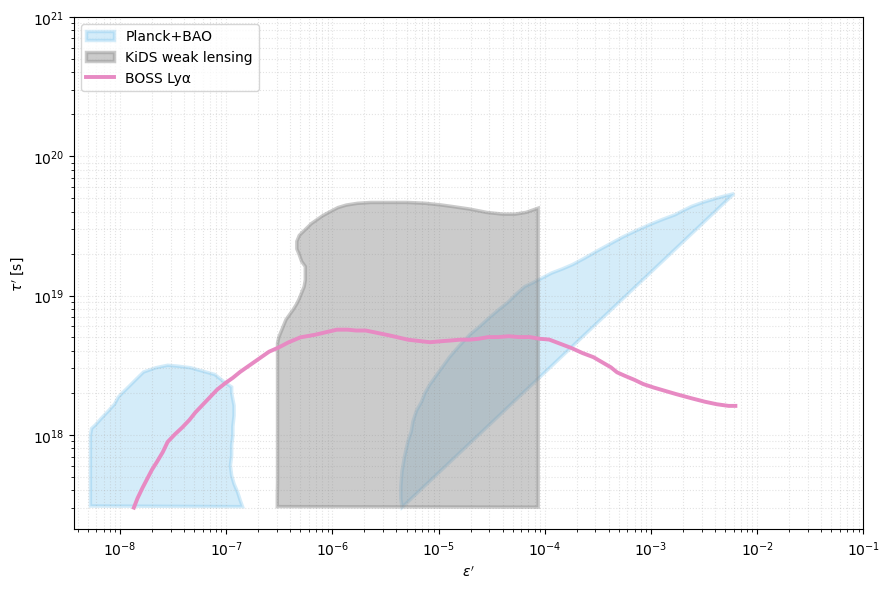

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

CSV_PATH = "wpd_datasets.csv"
f_mon = 0.1

def extract_xy(df, xcol, ycol):
    sub = df[[xcol, ycol]].iloc[1:].copy()
    sub.columns = ["eps","tau"]
    sub = sub.apply(pd.to_numeric, errors="coerce").dropna()
    eps = sub["eps"].to_numpy()
    tau = sub["tau"].to_numpy()
    m = np.isfinite(eps) & np.isfinite(tau) & (eps > 0) & (tau > 0)
    return eps[m], tau[m]

def eps_to_epsprime(eps):
    eps = np.asarray(eps, float)
    # valid only for eps < 0.5
    return (1.0 - eps)/np.sqrt(1.0 - 2.0*eps) - 1.0

def transform(eps, tau, f_mon):
    epsp = eps_to_epsprime(eps)
    taup = tau / f_mon
    m = np.isfinite(epsp) & np.isfinite(taup) & (epsp > 0) & (taup > 0)
    return epsp[m], taup[m]

def add_poly(ax, x, y, color, alpha, label=None, z=1, edge=True):
    xy = np.column_stack([x, y])
    ax.add_patch(Polygon(
        xy, closed=True,
        facecolor=color, alpha=alpha,
        edgecolor=color if edge else "none",
        linewidth=2.5 if edge else 0.0,
        label=label, zorder=z
    ))

raw = pd.read_csv(CSV_PATH)

kids_eps,kids_tau = extract_xy(raw,"Default Dataset","Unnamed: 1")
p1_eps,p1_tau     = extract_xy(raw,"Dataset 1","Unnamed: 3")
p2_eps,p2_tau     = extract_xy(raw,"Dataset 2","Unnamed: 5")
boss_eps,boss_tau = extract_xy(raw,"BOSS","Unnamed: 7")

kids_x,kids_y = transform(kids_eps,kids_tau,f_mon)
p1_x,p1_y     = transform(p1_eps,p1_tau,f_mon)
p2_x,p2_y     = transform(p2_eps,p2_tau,f_mon)
boss_x,boss_y = transform(boss_eps,boss_tau,f_mon)

fig, ax = plt.subplots(figsize=(9,6))
ax.set_xscale("log"); ax.set_yscale("log")

# Colors
c_planck = "#56B4E9"
c_kids   = "#8c8c8c"
c_boss   = "#e78ac3"

add_poly(ax, p1_x, p1_y, c_planck, 0.25, label="Planck+BAO", z=1, edge=True)
add_poly(ax, p2_x, p2_y, c_planck, 0.25, label="_nolegend_", z=1, edge=True)
add_poly(ax, kids_x, kids_y, c_kids, 0.45, label="KiDS weak lensing", z=3, edge=True)

# BOSS as boundary line (and optionally fill below — your choice)
ax.plot(boss_x, boss_y, color=c_boss, lw=2.8, label="BOSS Lyα", zorder=10)

ax.set_xlabel(r"$\epsilon'$")
ax.set_ylabel(r"$\tau'$ [s]")

ax.grid(True, which="both", ls=":", alpha=0.35)
ax.legend(loc="upper left")

# auto limits that won't hide the leftmost transformed stuff
ax.set_xlim(max(1e-12, np.min(np.concatenate([p1_x,p2_x,boss_x]))*0.7), 1e-1)
ax.set_ylim(np.min(np.concatenate([kids_y,p1_y,p2_y,boss_y]))*0.7, 1e21)

plt.tight_layout()
plt.show()